# Telco Customer Churn Prediction

Build a machine learning workflow to identify customers who are likely to leave the company.

The project includes exploratory data analysis, feature engineering, preprocessing, model comparison, and hyperparameter optimization.

## 1. Problem Definition

Develop a classification model that predicts whether a telecom customer will churn based on demographic, account, service, and billing information.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import warnings
warnings.simplefilter(action="ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 170)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

## 2. Load and Prepare the Dataset

Load the Telco Customer Churn dataset and correct data type issues before starting the exploratory analysis.

In [2]:
df = pd.read_csv("Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.65,Yes


In [3]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Convert target variable to binary format
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 3. Initial Data Exploration

Inspect the structure, data types, missing values, and basic descriptive statistics of the dataset.

In [4]:
def check_df(dataframe, head=5):
    """
    Display a quick overview of a pandas DataFrame.
    """

    print("##################### Shape #####################")
    print(dataframe.shape)

    print("\n##################### Data Types #####################")
    print(dataframe.dtypes)

    print("\n##################### Head #####################")
    print(dataframe.head(head))

    print("\n##################### Tail #####################")
    print(dataframe.tail(head))

    print("\n##################### Missing Values #####################")
    missing = dataframe.isnull().sum()
    missing_percent = 100 * missing / len(dataframe)

    print(
        pd.DataFrame({
            "Missing": missing,
            "Missing %": missing_percent
        })
    )

    print("\n##################### Duplicated Rows #####################")
    print(dataframe.duplicated().sum())

    print("\n##################### Unique Values #####################")
    print(dataframe.nunique())

    print("\n##################### Quantiles #####################")
    print(
        dataframe.select_dtypes(include="number")
        .quantile([0, 0.05, 0.50, 0.95, 0.99, 1])
        .T
    )

In [5]:
check_df(df)

##################### Shape #####################
(7043, 21)

##################### Data Types #####################
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

##################### Head #####################
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService     MultipleLines InternetService OnlineSecurity OnlineBackup DeviceProtection TechSupport  \
0  7590-VHVEG  Female              0     Yes         No     

## 4. Identify Variable Types

Identify categorical, numerical, and high cardinality categorical variables to prepare for exploratory data analysis.

In [6]:
def grab_col_names(dataframe, cat_th=10, car_th=20):
    """
    Returns the names of categorical, numerical and categorical but cardinal variables.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Input dataframe.
    cat_th : int, default=10
        Threshold for numerical but categorical variables.
    car_th : int, default=20
        Threshold for categorical but cardinal variables.

    Returns
    -------
    cat_cols : list
        Categorical variables.
    num_cols : list
        Numerical variables.
    cat_but_car : list
        Categorical but cardinal variables.
    """

    cat_cols = [
        col for col in dataframe.columns
        if dataframe[col].dtype == "O"
    ]

    num_but_cat = [
        col for col in dataframe.columns
        if dataframe[col].nunique() < cat_th
        and dataframe[col].dtype != "O"
    ]

    cat_but_car = [
        col for col in dataframe.columns
        if dataframe[col].nunique() > car_th
        and dataframe[col].dtype == "O"
    ]

    cat_cols = cat_cols + num_but_cat

    cat_cols = [
        col for col in cat_cols
        if col not in cat_but_car
    ]

    num_cols = [
        col for col in dataframe.columns
        if dataframe[col].dtype != "O"
        and col not in num_but_cat
    ]

    print(f"Observations : {dataframe.shape[0]}")
    print(f"Variables    : {dataframe.shape[1]}")
    print(f"cat_cols     : {len(cat_cols)}")
    print(f"num_cols     : {len(num_cols)}")
    print(f"cat_but_car  : {len(cat_but_car)}")
    print(f"num_but_cat  : {len(num_but_cat)}")

    return cat_cols, num_cols, cat_but_car

In [7]:
cat_cols, num_cols, cat_but_car = grab_col_names(df)

Observations : 7043
Variables    : 21
cat_cols     : 17
num_cols     : 3
cat_but_car  : 1
num_but_cat  : 2


## 5. Categorical Variable Analysis

Analyze the distribution of categorical variables and examine their relationship with the target variable.

In [8]:
def cat_summary(dataframe, col_name, plot=False):

    summary = pd.DataFrame({
        col_name: dataframe[col_name].value_counts(),
        "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)
    })

    print(summary)

    print("#" * 50)

    if plot:
        sns.countplot(
            x=col_name,
            data=dataframe
        )
        plt.xticks(rotation=45)
        plt.show()

In [9]:
for col in cat_cols:
    cat_summary(df, col)

        gender  Ratio
gender               
Male      3555 50.476
Female    3488 49.524
##################################################
         Partner  Ratio
Partner                
No          3641 51.697
Yes         3402 48.303
##################################################
            Dependents  Ratio
Dependents                   
No                4933 70.041
Yes               2110 29.959
##################################################
              PhoneService  Ratio
PhoneService                     
Yes                   6361 90.317
No                     682  9.683
##################################################
                  MultipleLines  Ratio
MultipleLines                         
No                         3390 48.133
Yes                        2971 42.184
No phone service            682  9.683
##################################################
                 InternetService  Ratio
InternetService                        
Fiber optic                 30

## 6. Target Analysis with Categorical Variables

Analyze how the target variable changes across different categorical features.

In [10]:
def target_summary_with_cat(dataframe, target, categorical_col):

    summary = dataframe.groupby(categorical_col)[target].agg(
        ["mean", "count"]
    )

    summary.columns = ["TARGET_MEAN", "COUNT"]

    print(summary)

    print("#" * 50)

In [11]:
for col in cat_cols:
    if col != "Churn":
        target_summary_with_cat(df, "Churn", col)

        TARGET_MEAN  COUNT
gender                    
Female        0.269   3488
Male          0.262   3555
##################################################
         TARGET_MEAN  COUNT
Partner                    
No             0.330   3641
Yes            0.197   3402
##################################################
            TARGET_MEAN  COUNT
Dependents                    
No                0.313   4933
Yes               0.155   2110
##################################################
              TARGET_MEAN  COUNT
PhoneService                    
No                  0.249    682
Yes                 0.267   6361
##################################################
                  TARGET_MEAN  COUNT
MultipleLines                       
No                      0.250   3390
No phone service        0.249    682
Yes                     0.286   2971
##################################################
                 TARGET_MEAN  COUNT
InternetService                    
DSL         

### Interpretation

Several service-related variables appear to be associated with customer churn. In particular, contract type, online security, technical support, and internet service show noticeable differences in churn rates across categories.

## 7. Numerical Variable Analysis

Analyze the distribution of numerical variables and examine their relationship with the target variable.

In [12]:
def num_summary(dataframe, numerical_col, plot=False):

    quantiles = [0.05, 0.10, 0.25, 0.50,
                 0.75, 0.90, 0.95, 0.99]

    print(dataframe[numerical_col].describe(quantiles).T)

    print("#" * 50)

    if plot:
        dataframe[numerical_col].hist(bins=20)
        plt.xlabel(numerical_col)
        plt.title(numerical_col)
        plt.show()

In [13]:
for col in num_cols:
    num_summary(df, col)

count   7043.000
mean      32.371
std       24.559
min        0.000
5%         1.000
10%        2.000
25%        9.000
50%       29.000
75%       55.000
90%       69.000
95%       72.000
99%       72.000
max       72.000
Name: tenure, dtype: float64
##################################################
count   7043.000
mean      64.762
std       30.090
min       18.250
5%        19.650
10%       20.050
25%       35.500
50%       70.350
75%       89.850
90%      102.600
95%      107.400
99%      114.729
max      118.750
Name: MonthlyCharges, dtype: float64
##################################################
count   7032.000
mean    2283.300
std     2266.771
min       18.800
5%        49.605
10%       84.600
25%      401.450
50%     1397.475
75%     3794.738
90%     5976.640
95%     6923.590
99%     8039.883
max     8684.800
Name: TotalCharges, dtype: float64
##################################################


## 8. Target Analysis with Numerical Variables

Compare the average values of numerical variables across the target classes.

In [14]:
def target_summary_with_num(dataframe, target, numerical_col):

    summary = dataframe.groupby(target)[numerical_col].agg("mean")

    print(summary)

    print("#" * 50)

In [15]:
for col in num_cols:
    if col != "Churn":
        target_summary_with_num(df, "Churn", col)

Churn
0   37.570
1   17.979
Name: tenure, dtype: float64
##################################################
Churn
0   61.265
1   74.441
Name: MonthlyCharges, dtype: float64
##################################################
Churn
0   2555.344
1   1531.796
Name: TotalCharges, dtype: float64
##################################################


## 9. Missing Value Analysis

Identify missing values and evaluate whether they require further preprocessing before model development.

In [16]:
def missing_values_table(dataframe, return_columns=False):

    na_columns = [
        col for col in dataframe.columns
        if dataframe[col].isnull().sum() > 0
    ]

    n_miss = dataframe[na_columns].isnull().sum()

    ratio = (
        dataframe[na_columns]
        .isnull()
        .sum() / len(dataframe) * 100
    )

    missing_df = pd.concat(
        [n_miss, ratio],
        axis=1,
        keys=["Missing Values", "Ratio (%)"]
    )

    print(missing_df.sort_values("Missing Values", ascending=False))

    if return_columns:
        return na_columns

In [17]:
na_columns = missing_values_table(df, return_columns=True)

              Missing Values  Ratio (%)
TotalCharges              11      0.156


## 10. Outlier Analysis

Detect potential outliers in numerical variables using the IQR method and evaluate whether they require treatment.

In [18]:
def outlier_thresholds(dataframe, col_name, q1=0.05, q3=0.95):

    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)

    iqr = quartile3 - quartile1

    lower_limit = quartile1 - 1.5 * iqr
    upper_limit = quartile3 + 1.5 * iqr

    return lower_limit, upper_limit

In [19]:
def check_outlier(dataframe, col_name):

    lower_limit, upper_limit = outlier_thresholds(
        dataframe,
        col_name
    )

    return dataframe[
        (dataframe[col_name] < lower_limit) |
        (dataframe[col_name] > upper_limit)
    ].any(axis=None)

In [20]:
for col in num_cols:
    if col != "Churn":
        print(f"{col}: {check_outlier(df, col)}")

tenure: False
MonthlyCharges: False
TotalCharges: False


## 11. Feature Engineering

Create new variables that may improve the model's ability to identify customers who are likely to churn.

### 11.1 Customer Tenure Groups

Group customers according to how long they have stayed with the company.

In [21]:
df.loc[df["tenure"] < 12, "NEW_TENURE_CAT"] = "New"

df.loc[
    (df["tenure"] >= 12) &
    (df["tenure"] < 48),
    "NEW_TENURE_CAT"
] = "Regular"

df.loc[
    df["tenure"] >= 48,
    "NEW_TENURE_CAT"
] = "Loyal"

### 11.2 Engagement Features

Create features that represent customer commitment and contract engagement.

In [22]:
df["NEW_ENGAGED"] = np.where(
    df["Contract"].isin(["One year", "Two year"]),
    1,
    0
)

df["NEW_YOUNG_NOT_ENGAGED"] = np.where(
    (df["NEW_ENGAGED"] == 0) &
    (df["SeniorCitizen"] == 0),
    1,
    0
)

### 11.3 Protection and Support Features

Identify customers who do not actively use backup, device protection, or technical support services.

In [23]:
df["NEW_NO_PROT"] = np.where(
    (df["OnlineBackup"] != "Yes") |
    (df["DeviceProtection"] != "Yes") |
    (df["TechSupport"] != "Yes"),
    1,
    0
)

### 11.4 Service Usage Features

Measure how many telecom services each customer actively uses.

In [24]:
service_cols = [
    "PhoneService",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["NEW_TOTAL_SERVICES"] = (
    df[service_cols]
    .eq("Yes")
    .sum(axis=1)
)

In [25]:
df["NEW_FLAG_ANY_STREAMING"] = np.where(
    (df["StreamingTV"] == "Yes") |
    (df["StreamingMovies"] == "Yes"),
    1,
    0
)

In [26]:
df["NEW_FLAG_AUTOPAYMENT"] = np.where(
    df["PaymentMethod"].isin([
        "Bank transfer (automatic)",
        "Credit card (automatic)"
    ]),
    1,
    0
)

### 11.5 Charge-Based Features

Create new variables that capture average customer spending, price changes, and service-level cost.

In [27]:
df["NEW_AVG_CHARGES"] = (
    df["TotalCharges"] /
    (df["tenure"] + 1)
)

df["NEW_INCREASE"] = (
    df["NEW_AVG_CHARGES"] /
    df["MonthlyCharges"]
)

df["NEW_AVG_SERVICE_FEE"] = (
    df["MonthlyCharges"] /
    (df["NEW_TOTAL_SERVICES"] + 1)
)

In [28]:
df.head()
df.shape

(7043, 31)

## 12. Encoding Categorical Variables

Convert categorical features into numerical representations suitable for machine learning models.

In [29]:
cat_cols, num_cols, cat_but_car = grab_col_names(df)

Observations : 7043
Variables    : 31
cat_cols     : 24
num_cols     : 6
cat_but_car  : 1
num_but_cat  : 8


### 12.1 Label Encoding

Encode binary categorical variables as 0 and 1.

In [30]:
def label_encoder(dataframe, binary_col):
    """
    Apply label encoding to a binary categorical feature.
    """
    encoder = LabelEncoder()
    dataframe[binary_col] = encoder.fit_transform(dataframe[binary_col])

    return dataframe

In [31]:
binary_cols = [
    col
    for col in df.select_dtypes(include=["object", "string"]).columns
    if df[col].nunique(dropna=False) == 2
    and col != "customerID"
]

binary_cols

['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

In [32]:
for col in binary_cols:
    df = label_encoder(df, col)

### 12.2 One-Hot Encoding

Apply one-hot encoding to categorical variables containing more than two categories.

In [33]:
cat_cols = [
    col
    for col in cat_cols
    if col not in binary_cols
    and col not in ["Churn", "NEW_TOTAL_SERVICES"]
]

cat_cols

['MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaymentMethod',
 'NEW_TENURE_CAT',
 'SeniorCitizen',
 'NEW_ENGAGED',
 'NEW_YOUNG_NOT_ENGAGED',
 'NEW_NO_PROT',
 'NEW_FLAG_ANY_STREAMING',
 'NEW_FLAG_AUTOPAYMENT']

In [34]:
def one_hot_encoder(dataframe, categorical_cols, drop_first=False):
    """
    Apply one-hot encoding to categorical variables.
    """
    return pd.get_dummies(
        dataframe,
        columns=categorical_cols,
        drop_first=drop_first
    )

In [35]:
df = one_hot_encoder(
    df,
    cat_cols,
    drop_first=True
)

df.head()
df.shape

(7043, 43)

## 13. Standardization of Numerical Variables

Standardize continuous numerical features before model development.

In [36]:
cat_cols, num_cols, cat_but_car = grab_col_names(df)

num_cols

Observations : 7043
Variables    : 43
cat_cols     : 36
num_cols     : 6
cat_but_car  : 1
num_but_cat  : 36


['tenure',
 'MonthlyCharges',
 'TotalCharges',
 'NEW_AVG_CHARGES',
 'NEW_INCREASE',
 'NEW_AVG_SERVICE_FEE']

In [37]:
scale_cols = [
    col
    for col in num_cols
    if col not in ["Churn"]
]

In [38]:
scaler = StandardScaler()

df[scale_cols] = scaler.fit_transform(df[scale_cols])

df.head()

,customerID,gender,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,NEW_TOTAL_SERVICES,NEW_AVG_CHARGES,NEW_INCREASE,NEW_AVG_SERVICE_FEE,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,NEW_TENURE_CAT_New,NEW_TENURE_CAT_Regular,SeniorCitizen_1,NEW_ENGAGED_1,NEW_YOUNG_NOT_ENGAGED_1,NEW_NO_PROT_1,NEW_FLAG_ANY_STREAMING_1,NEW_FLAG_AUTOPAYMENT_1
0,7590-VHVEG,0,1,0,-1.277,0,1,-1.160,-0.994,0,1,-1.447,-2.663,-0.311,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,True,True,False,False
1,5575-GNVDE,1,0,0,0.066,1,0,-0.260,-0.174,0,3,-0.167,0.329,-0.410,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,True,False,True,False,True,False,False
2,3668-QPYBK,1,0,0,-1.237,1,1,-0.363,-0.960,1,3,-0.755,-1.531,-0.522,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,True,True,False,False
3,7795-CFOCW,1,0,0,0.514,0,0,-0.747,-0.195,0,3,-0.625,0.316,-0.939,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,True,False,True,False,True,False,True
4,9237-HQITU,0,0,0,-1.237,1,1,0.197,-0.940,1,1,-0.280,-1.227,2.636,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,True,True,False,False


In [39]:
df[scale_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.000,-0.000,1.000,-1.318,-0.952,-0.137,0.921,1.614
MonthlyCharges,7043.000,-0.000,1.000,-1.546,-0.973,0.186,0.834,1.794
TotalCharges,7032.000,0.000,1.000,-0.999,-0.830,-0.391,0.667,2.824
NEW_AVG_CHARGES,7032.000,-0.000,1.000,-1.635,-1.077,0.065,0.845,1.963
NEW_INCREASE,7032.000,0.000,1.000,-2.857,-0.076,0.401,0.591,1.985
NEW_AVG_SERVICE_FEE,7043.000,-0.000,1.000,-1.217,-0.796,-0.230,0.524,3.155


## 14. Model Development

Evaluate multiple classification algorithms using cross-validation and compare their performance across common classification metrics.

In [48]:
# Target variable
y = df["Churn"]

# Feature matrix
X = df.drop(
    ["Churn", "customerID"],
    axis=1
)

# Final data check before modeling
print(f"X Shape: {X.shape}")
print(f"y Shape: {y.shape}")
print(f"Missing Values in X: {X.isnull().sum().sum()}")
print(f"Missing Values in y: {y.isnull().sum()}")

X Shape: (7032, 41)
y Shape: (7032,)
Missing Values in X: 0
Missing Values in y: 0


In [49]:
#Control for missing values
assert X.isnull().sum().sum() == 0, "X contains missing values."
assert y.isnull().sum() == 0, "y contains missing values."

### 14.2 Classification Models

Define multiple classification algorithms to compare their baseline performance under the same cross-validation strategy.

In [50]:
models = [
    ("LR", LogisticRegression(max_iter=1000)),
    ("KNN", KNeighborsClassifier()),
    ("CART", DecisionTreeClassifier(random_state=17)),
    ("RF", RandomForestClassifier(random_state=17)),
    ("SVM", SVC()),
    ("XGBoost", XGBClassifier(random_state=17)),
    ("LightGBM", LGBMClassifier(random_state=17, verbose=-1)),
    ("CatBoost", CatBoostClassifier(random_state=17, verbose=False))
]

### 14.3 Evaluation Metrics

Use multiple classification metrics to evaluate model performance from different perspectives.

In [51]:
scoring = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]

### 14.4 Model Comparison

Compare all classification models using 5-fold cross-validation and summarize their average performance.

In [52]:
results = []

for name, model in models:

    cv_results = cross_validate(
        model,
        X,
        y,
        cv=5,
        scoring=scoring
    )

    results.append({
        "Model": name,
        "Accuracy": cv_results["test_accuracy"].mean(),
        "Precision": cv_results["test_precision"].mean(),
        "Recall": cv_results["test_recall"].mean(),
        "F1": cv_results["test_f1"].mean(),
        "ROC_AUC": cv_results["test_roc_auc"].mean()
    })

model_results = pd.DataFrame(results)

In [53]:
model_results.sort_values(
    by="ROC_AUC",
    ascending=False
).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,LR,0.804,0.663,0.536,0.593,0.850
7,CatBoost,0.798,0.651,0.519,0.578,0.839
6,LightGBM,0.796,0.643,0.522,0.576,0.834
3,RF,0.790,0.637,0.487,0.552,0.825
5,XGBoost,0.783,0.610,0.508,0.554,0.824
4,SVM,0.800,0.672,0.486,0.564,0.801
1,KNN,0.774,0.585,0.521,0.551,0.784
2,CART,0.730,0.492,0.498,0.494,0.656


### Model Comparison - Interpretation

Logistic Regression achieved the strongest overall baseline performance, with the highest Accuracy, Recall, F1 Score, and ROC-AUC.

CatBoost and LightGBM also produced competitive results, while CART showed the weakest performance among the evaluated models.

These results demonstrate that more complex models do not necessarily outperform simpler algorithms before hyperparameter optimization.

## 15. Hyperparameter Optimization

Optimize the hyperparameters of ensemble models using GridSearchCV and evaluate their performance after tuning.

In [54]:
# Create the Random Forest model with a fixed random state
# random_state ensures reproducible results
rf_model = RandomForestClassifier(random_state=17)


# Define the hyperparameter search space
# GridSearchCV will try different combinations of these values
rf_params = {
    "max_depth": [5, 8, None],                 # Maximum depth of each tree
    "max_features": [3, 5, 7, "sqrt"],         # Number of features considered at each split
    "min_samples_split": [2, 5, 8],            # Minimum samples required to split a node
    "n_estimators": [100, 200, 500]            # Number of trees in the forest
}

In [55]:
# Search for the best hyperparameter combination
rf_grid = GridSearchCV(
    estimator=rf_model,       # Model to optimize
    param_grid=rf_params,     # Hyperparameter combinations to test
    scoring="roc_auc",        # Metric used to select the best combination
    cv=5,                     # 5-fold cross-validation
    n_jobs=-1                 # Use all available CPU cores
)

# Train and evaluate all parameter combinations
rf_grid.fit(X, y)

,estimator,RandomForestC...ndom_state=17)
,param_grid,"{'max_depth': [5, 8, ...], 'max_features': [3, 5, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,500


In [56]:
# Display the best hyperparameter combination
print("Best Parameters:")
print(rf_grid.best_params_)

# Display the best mean ROC-AUC obtained during GridSearchCV
print("\nBest CV ROC-AUC:")
print(round(rf_grid.best_score_, 3))

Best Parameters:
{'max_depth': 8, 'max_features': 5, 'min_samples_split': 5, 'n_estimators': 500}

Best CV ROC-AUC:
0.845


In [57]:
# Create the final Random Forest model
# using the best parameters found by GridSearchCV
rf_final = RandomForestClassifier(
    random_state=17,
    **rf_grid.best_params_
)

In [58]:
# Evaluate the tuned Random Forest model
# using the same cross-validation strategy and metrics
rf_cv = cross_validate(
    rf_final,
    X,
    y,
    cv=5,
    scoring=scoring
)


# Store the average cross-validation scores
rf_final_results = {
    "Model": "RF Tuned",
    "Accuracy": rf_cv["test_accuracy"].mean(),
    "Precision": rf_cv["test_precision"].mean(),
    "Recall": rf_cv["test_recall"].mean(),
    "F1": rf_cv["test_f1"].mean(),
    "ROC_AUC": rf_cv["test_roc_auc"].mean()
}


# Display tuned model performance
pd.DataFrame([rf_final_results]).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,RF Tuned,0.799,0.666,0.490,0.565,0.845


### 15.2 XGBoost Hyperparameter Optimization

Optimize the main XGBoost hyperparameters using GridSearchCV and evaluate the tuned model with cross-validation.

In [59]:
# Create the XGBoost model
xgb_model = XGBClassifier(
    random_state=17,
    eval_metric="logloss"
)


# Define the hyperparameter search space
xgb_params = {
    "learning_rate": [0.1, 0.01, 0.001],   # Step size used during boosting
    "max_depth": [5, 8, 12],                # Maximum depth of each tree
    "n_estimators": [100, 500, 1000],       # Number of boosting rounds / trees
    "colsample_bytree": [0.5, 0.7, 1.0]     # Fraction of features used by each tree
}

In [60]:
# Search for the best XGBoost hyperparameter combination
xgb_grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_params,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

# Train and evaluate all parameter combinations
xgb_grid.fit(X, y)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.5, 0.7, ...], 'learning_rate': [0.1, 0.01, ...], 'max_depth': [5, 8, ...], 'n_estimators': [100, 500, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [61]:
# Display the best hyperparameter combination
print("Best Parameters:")
print(xgb_grid.best_params_)

# Display the best mean ROC-AUC obtained during GridSearchCV
print("\nBest CV ROC-AUC:")
print(round(xgb_grid.best_score_, 3))

Best Parameters:
{'colsample_bytree': 0.5, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 500}

Best CV ROC-AUC:
0.845


In [62]:
# Create the final XGBoost model
# using the best parameters found by GridSearchCV
xgb_final = XGBClassifier(
    random_state=17,
    eval_metric="logloss",
    **xgb_grid.best_params_
)

In [63]:
# Evaluate the tuned XGBoost model
xgb_cv = cross_validate(
    xgb_final,
    X,
    y,
    cv=5,
    scoring=scoring
)


# Store the average cross-validation scores
xgb_final_results = {
    "Model": "XGBoost Tuned",
    "Accuracy": xgb_cv["test_accuracy"].mean(),
    "Precision": xgb_cv["test_precision"].mean(),
    "Recall": xgb_cv["test_recall"].mean(),
    "F1": xgb_cv["test_f1"].mean(),
    "ROC_AUC": xgb_cv["test_roc_auc"].mean()
}


# Display tuned model performance
pd.DataFrame([xgb_final_results]).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,XGBoost Tuned,0.800,0.659,0.517,0.579,0.845


### 15.3 LightGBM Hyperparameter Optimization

Optimize the main LightGBM hyperparameters using GridSearchCV and evaluate the tuned model with cross-validation.

In [64]:
# Create the LightGBM model
lgbm_model = LGBMClassifier(
    random_state=17,
    verbose=-1
)


# Define the hyperparameter search space
lgbm_params = {
    "learning_rate": [0.01, 0.05, 0.1],    # Step size used during boosting
    "n_estimators": [100, 300, 500],         # Number of boosting rounds / trees
    "max_depth": [-1, 5, 8],                 # Maximum tree depth (-1 means no limit)
    "num_leaves": [15, 31, 63]               # Maximum number of leaves in each tree
}

In [65]:
# Search for the best LightGBM hyperparameter combination
lgbm_grid = GridSearchCV(
    estimator=lgbm_model,
    param_grid=lgbm_params,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

# Train and evaluate all parameter combinations
lgbm_grid.fit(X, y)

,estimator,"LGBMClassifie...7, verbose=-1)"
,param_grid,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [-1, 5, ...], 'n_estimators': [100, 300, ...], 'num_leaves': [15, 31, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,boosting_type,'gbdt'


In [66]:
# Display the best hyperparameter combination
print("Best Parameters:")
print(lgbm_grid.best_params_)

# Display the best mean ROC-AUC obtained during GridSearchCV
print("\nBest CV ROC-AUC:")
print(round(lgbm_grid.best_score_, 3))

Best Parameters:
{'learning_rate': 0.01, 'max_depth': 8, 'n_estimators': 500, 'num_leaves': 15}

Best CV ROC-AUC:
0.845


In [67]:
# Create the final LightGBM model
# using the best parameters found by GridSearchCV
lgbm_final = LGBMClassifier(
    random_state=17,
    verbose=-1,
    **lgbm_grid.best_params_
)

In [68]:
# Evaluate the tuned LightGBM model
lgbm_cv = cross_validate(
    lgbm_final,
    X,
    y,
    cv=5,
    scoring=scoring
)


# Store the average cross-validation scores
lgbm_final_results = {
    "Model": "LightGBM Tuned",
    "Accuracy": lgbm_cv["test_accuracy"].mean(),
    "Precision": lgbm_cv["test_precision"].mean(),
    "Recall": lgbm_cv["test_recall"].mean(),
    "F1": lgbm_cv["test_f1"].mean(),
    "ROC_AUC": lgbm_cv["test_roc_auc"].mean()
}


# Display tuned model performance
pd.DataFrame([lgbm_final_results]).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,LightGBM Tuned,0.801,0.657,0.530,0.587,0.845


### 15.4 CatBoost Hyperparameter Optimization

Optimize the main CatBoost hyperparameters using GridSearchCV and evaluate the tuned model with cross-validation.

In [69]:
# Create the CatBoost model
catboost_model = CatBoostClassifier(
    random_state=17,
    verbose=False
)


# Define the hyperparameter search space
catboost_params = {
    "iterations": [200, 500],        # Number of boosting iterations / trees
    "learning_rate": [0.01, 0.1],    # Step size used during boosting
    "depth": [3, 6]                   # Maximum depth of each tree
}

In [70]:
# Search for the best CatBoost hyperparameter combination
catboost_grid = GridSearchCV(
    estimator=catboost_model,
    param_grid=catboost_params,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

# Train and evaluate all parameter combinations
catboost_grid.fit(X, y)

,estimator,CatBoostClass...verbose=False)
,param_grid,"{'depth': [3, 6], 'iterations': [200, 500], 'learning_rate': [0.01, 0.1]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False


In [71]:
# Display the best hyperparameter combination
print("Best Parameters:")
print(catboost_grid.best_params_)

# Display the best mean ROC-AUC obtained during GridSearchCV
print("\nBest CV ROC-AUC:")
print(round(catboost_grid.best_score_, 3))

Best Parameters:
{'depth': 6, 'iterations': 500, 'learning_rate': 0.01}

Best CV ROC-AUC:
0.847


In [72]:
# Create the final CatBoost model
# using the best parameters found by GridSearchCV
catboost_final = CatBoostClassifier(
    random_state=17,
    verbose=False,
    **catboost_grid.best_params_
)

In [74]:
# Evaluate the tuned CatBoost model
catboost_cv = cross_validate(
    catboost_final,
    X,
    y,
    cv=5,
    scoring=scoring
)


# Store the average cross-validation scores
catboost_final_results = {
    "Model": "CatBoost Tuned",
    "Accuracy": catboost_cv["test_accuracy"].mean(),
    "Precision": catboost_cv["test_precision"].mean(),
    "Recall": catboost_cv["test_recall"].mean(),
    "F1": catboost_cv["test_f1"].mean(),
    "ROC_AUC": catboost_cv["test_roc_auc"].mean()
}


# Display tuned model performance
pd.DataFrame([catboost_final_results]).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,CatBoost Tuned,0.803,0.669,0.511,0.580,0.847


## 16. Tuned Model Comparison

Compare the optimized ensemble models and evaluate whether hyperparameter tuning improved their performance.

In [75]:
# Combine tuned model results
tuned_results = pd.DataFrame([
    rf_final_results,
    xgb_final_results,
    lgbm_final_results,
    catboost_final_results
])

tuned_results.sort_values(
    by="ROC_AUC",
    ascending=False
).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
3,CatBoost Tuned,0.803,0.669,0.511,0.580,0.847
0,RF Tuned,0.799,0.666,0.490,0.565,0.845
1,XGBoost Tuned,0.800,0.659,0.517,0.579,0.845
2,LightGBM Tuned,0.801,0.657,0.530,0.587,0.845


In [76]:
# Select the corresponding baseline ensemble models
baseline_ensemble_results = model_results[
    model_results["Model"].isin([
        "RF",
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ])
].copy()

baseline_ensemble_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
3,RF,0.790,0.637,0.487,0.552,0.825
5,XGBoost,0.783,0.610,0.508,0.554,0.824
6,LightGBM,0.796,0.643,0.522,0.576,0.834
7,CatBoost,0.798,0.651,0.519,0.578,0.839


In [77]:
comparison_results = pd.concat(
    [
        baseline_ensemble_results,
        tuned_results
    ],
    ignore_index=True
)

comparison_results.sort_values(
    by="ROC_AUC",
    ascending=False
).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
7,CatBoost Tuned,0.803,0.669,0.511,0.580,0.847
4,RF Tuned,0.799,0.666,0.490,0.565,0.845
5,XGBoost Tuned,0.800,0.659,0.517,0.579,0.845
6,LightGBM Tuned,0.801,0.657,0.530,0.587,0.845
3,CatBoost,0.798,0.651,0.519,0.578,0.839
2,LightGBM,0.796,0.643,0.522,0.576,0.834
0,RF,0.790,0.637,0.487,0.552,0.825
1,XGBoost,0.783,0.610,0.508,0.554,0.824


### Interpretation

Hyperparameter tuning improved the performance of some ensemble models, while the degree of improvement varied across algorithms.

The tuned models are compared using the same evaluation metrics to identify the strongest overall classifier.

## 17. Feature Importance

Analyze the contribution of each feature to the predictions of the best-performing tuned ensemble model.

In [78]:
# Fit the final tuned CatBoost model on the full dataset
# This is required to obtain feature importance values
catboost_final.fit(X, y)

CatBoostClassifier(depth=6, iterations=500, learning_rate=0.01, random_state=17, verbose=False)

In [79]:
# Create a dataframe containing feature importance scores
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": catboost_final.feature_importances_
})

# Sort features from most to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
3,tenure,13.168
36,NEW_ENGAGED_1,11.149
11,NEW_AVG_SERVICE_FEE,7.959
10,NEW_INCREASE,6.771
29,Contract_Two year,6.536
6,MonthlyCharges,6.085
14,InternetService_Fiber optic,4.935
7,TotalCharges,4.538
9,NEW_AVG_CHARGES,3.480
5,PaperlessBilling,3.385


### 17.1 Feature Importance Visualization

Visualize the most influential features used by the tuned CatBoost model.

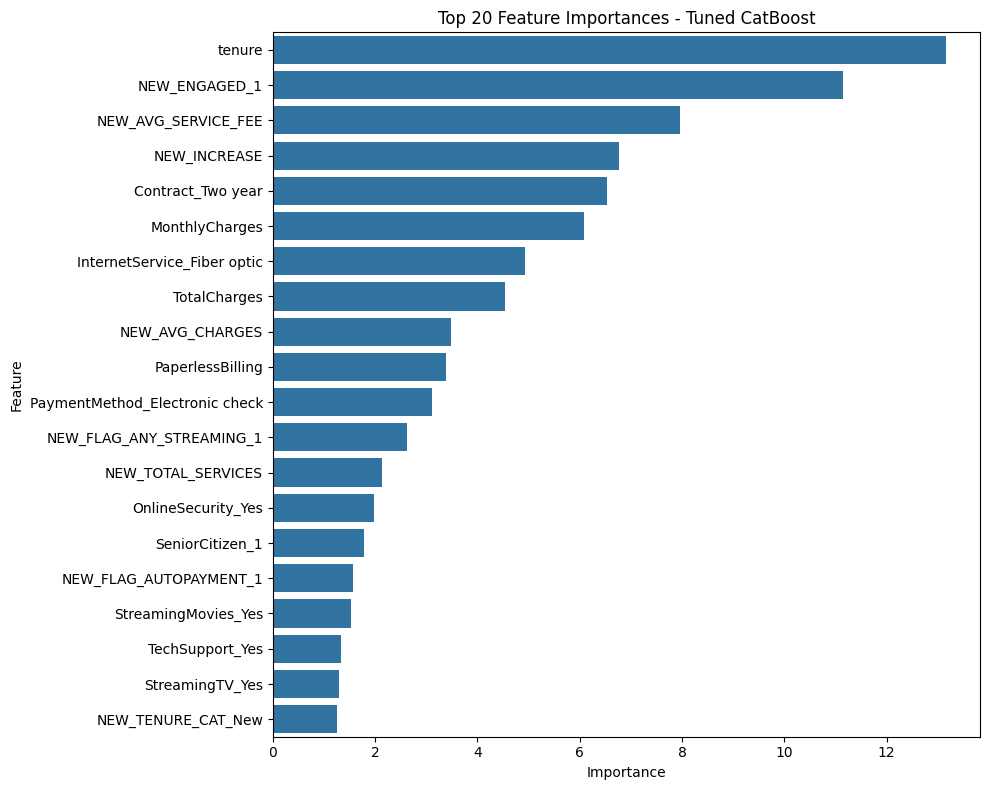

In [80]:
# Plot the 20 most important features
plt.figure(figsize=(10, 8))

sns.barplot(
    data=feature_importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Feature Importances - Tuned CatBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Feature Importance - Interpretation

Tenure is the most influential feature in the tuned CatBoost model.

Several engineered features, including `NEW_ENGAGED`, `NEW_AVG_SERVICE_FEE`, `NEW_INCREASE`, and `NEW_AVG_CHARGES`, also rank among the most important predictors. This indicates that the feature engineering process provided useful additional information for churn prediction.

Contract type, monthly charges, internet service type, and total charges also play an important role in the model's predictions.

## 18. Final Model Evaluation

Compare the best baseline model with the optimized ensemble models to identify the strongest overall model.

In [81]:
# Select the Logistic Regression baseline result
lr_result = model_results[
    model_results["Model"] == "LR"
].copy()


# Combine Logistic Regression with the tuned ensemble models
final_comparison = pd.concat(
    [
        lr_result,
        tuned_results
    ],
    ignore_index=True
)


# Sort all final candidates by ROC-AUC
final_comparison = final_comparison.sort_values(
    by="ROC_AUC",
    ascending=False
)

final_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,LR,0.804,0.663,0.536,0.593,0.850
4,CatBoost Tuned,0.803,0.669,0.511,0.580,0.847
1,RF Tuned,0.799,0.666,0.490,0.565,0.845
2,XGBoost Tuned,0.800,0.659,0.517,0.579,0.845
3,LightGBM Tuned,0.801,0.657,0.530,0.587,0.845


## 19. Conclusion

Multiple classification algorithms were evaluated for customer churn prediction using 5-fold cross-validation.

Hyperparameter optimization improved the performance of the ensemble models, with Tuned CatBoost achieving the highest ROC-AUC among them.

However, Logistic Regression remained the strongest overall model, achieving the highest ROC-AUC, Accuracy, Recall, and F1 Score.

Feature importance analysis of the tuned CatBoost model also showed that several engineered features contributed substantially to churn prediction, demonstrating the value of the feature engineering process.

Overall, the results show that model complexity does not necessarily guarantee better predictive performance and that both feature engineering and systematic model comparison are important parts of the machine learning workflow.